# PCA vs. OLS vs. Lasso vs. Post-Lasso (Double Selection)

This notebook builds on the previous covariance-matrix and PCA work and asks a sharper question: when predicting an asset's future return from a **large, correlated universe of predictors**, which modeling approach actually generalizes out of sample?

Four approaches are compared, all starting from the same covariance-driven simulation:

1. **Principal Component Regression (PCR)** — the PCA-based dimensionality reduction from the previous notebook, used here as a *predictive* model.
2. **OLS** — plain least squares on every available predictor, as a baseline.
3. **Lasso** — $L_1$-regularized regression that shrinks and selects.
4. **Post-Lasso / Double Selection ("double learning")** — Lasso for variable selection, followed by an unpenalized refit, in the spirit of Belloni, Chernozhukov & Hansen's double-selection estimator.

**The test**: fit every model once on 7.75 years of simulated daily data, then compare how closely each one's forecast *cumulative* return traces the actual cumulative return over the following, entirely unseen, 250 trading days.

## 1. Method Recap

- **PCR** regresses the target on the top $k$ principal components of the predictors, i.e. on $Z = X W_k$ where $W_k$ holds the leading eigenvectors of $\text{Cov}(X)$. It handles correlated predictors well but has no notion of which *individual* predictors matter — a true sparse signal can get diluted across components that aren't aligned with it.
- **OLS** minimizes $\|y - X\beta\|_2^2$ over *all* predictors with no penalty. With many correlated predictors and a finite sample, its coefficient estimates have high variance — it fits in-sample noise as readily as signal.
- **Lasso** minimizes $\|y - X\beta\|_2^2 + \lambda\|\beta\|_1$. The $L_1$ penalty sets many coefficients to exactly zero (variable selection) but *shrinks* every surviving coefficient toward zero — a real, systematic bias.
- **Post-Lasso / double selection** uses Lasso only to choose *which* predictors matter, via two independent sample splits (cross-fitting), then refits an ordinary, unpenalized OLS on the *intersection* of the two selected sets — predictors both halves agree are relevant. This targets the same predictors Lasso would pick, but removes the shrinkage bias in their estimated size.

## 2. Simulating a Large Asset Universe

400 assets across 20 sectors, 8 years of daily returns (2,016 trading days). Within-sector correlation (0.45) is much higher than cross-sector correlation (0.08) — the same block structure used in the covariance-matrix notebook, just scaled up to a realistic "large universe" size.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (7, 4.2), 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'grid.alpha': 0.35,
})

rng = np.random.default_rng(11)

n_sectors, sector_size = 20, 20
N = n_sectors * sector_size                       # 400 assets
sectors = np.repeat([f"S{i+1}" for i in range(n_sectors)], sector_size)

corr = np.full((N, N), 0.08)
for s in range(n_sectors):
    idx = np.where(sectors == f"S{s+1}")[0]
    corr[np.ix_(idx, idx)] = 0.45
np.fill_diagonal(corr, 1.0)

vols = rng.uniform(0.10, 0.30, N)                  # annual volatility per asset
cov_annual = np.outer(vols, vols) * corr
mu_annual = rng.uniform(0.02, 0.10, N)             # annual expected return per asset

n_years = 8
n_days = n_years * 252
dt = 1 / 252
R = rng.multivariate_normal(mu_annual * dt, cov_annual * dt, size=n_days)

print(f"Simulated returns: {R.shape[0]} days x {R.shape[1]} assets across {n_sectors} sectors")

Simulated returns: 2016 days x 400 assets across 20 sectors


**Diagram — correlation structure.** The block-diagonal pattern (20 sector blocks of 20 assets each) is the source of the multicollinearity that makes OLS unstable and gives PCA/Lasso something meaningful to exploit.

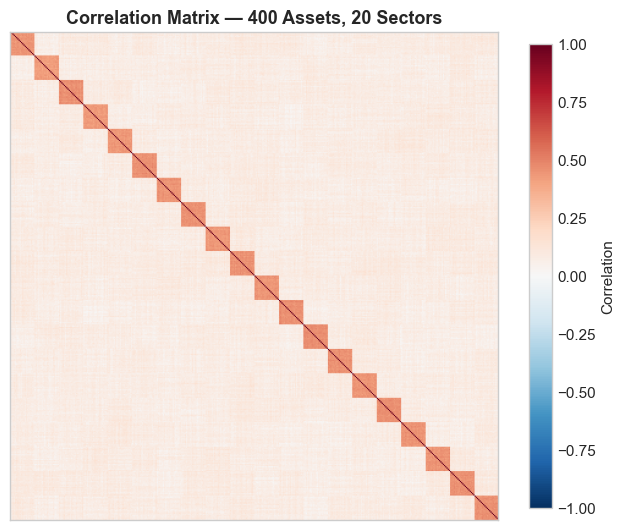

In [2]:
sample_corr = np.corrcoef(R, rowvar=False)

fig, ax = plt.subplots(figsize=(6.5, 5.8))
im = ax.imshow(sample_corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f'Correlation Matrix — {N} Assets, {n_sectors} Sectors')
fig.colorbar(im, ax=ax, label='Correlation', shrink=0.85)
plt.tight_layout()
plt.show()

**Diagram — sector-level time series.** Rather than plotting 400 individual lines, each sector's equal-weighted cumulative return is shown, illustrating the spread of outcomes the model will have to disentangle.

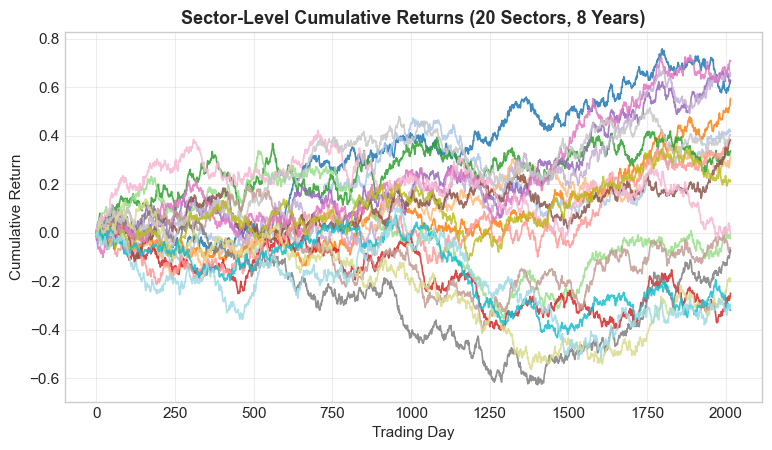

In [3]:
sector_cum_returns = np.zeros((n_days, n_sectors))
for s in range(n_sectors):
    idx = np.where(sectors == f"S{s+1}")[0]
    sector_cum_returns[:, s] = np.cumsum(R[:, idx].mean(axis=1))

fig, ax = plt.subplots(figsize=(9, 4.8))
cmap = plt.cm.tab20
for s in range(n_sectors):
    ax.plot(sector_cum_returns[:, s], color=cmap(s / n_sectors), linewidth=1.2, alpha=0.85)
ax.set_xlabel('Trading Day'); ax.set_ylabel('Cumulative Return')
ax.set_title('Sector-Level Cumulative Returns (20 Sectors, 8 Years)')
plt.show()

## 3. Constructing a Predictable Target

A realistic prediction target is built on top of the simulated universe: a **fund whose next-day return is driven by yesterday's returns of a small number of "leader" assets**, plus dominant idiosyncratic noise. Six leaders are chosen (one per handful of sectors), each with a modest true coefficient — the other 394 assets have *no* true predictive relationship, but remain correlated with the leaders through the sector structure above. This sparsity is exactly the setting Lasso and post-Lasso are designed for.

$$y_t = X_{t-1}\,\beta_{\text{true}} + \varepsilon_t, \qquad \beta_{\text{true}} \text{ nonzero at 6 of 400 positions}$$

The noise variance is calibrated so the *true, population* $R^2$ is about 15% — generous by the standards of real daily-return prediction, but low enough that overfitting to noise remains a genuine risk for a naive model.

In [4]:
leader_idx = [3, 55, 130, 210, 305, 370]
beta_vals = np.array([0.9, -0.8, 1.0, -0.9, 0.85, -0.75])
beta_true = np.zeros(N)
beta_true[leader_idx] = beta_vals

X_all = R[:-1]                       # lagged predictors, day t-1
signal = X_all @ beta_true           # true predictable component of day-t return
snr = 0.15                           # target population R^2
noise_std = signal.std() * np.sqrt((1 - snr) / snr)
y_all = signal + rng.normal(0, noise_std, size=len(signal))

pop_r2 = signal.var() / y_all.var()
print(f"Predictors: {N}  |  True nonzero predictors: {len(leader_idx)}")
print(f"Population R^2 of the true model: {pop_r2:.3f}")

Predictors: 400  |  True nonzero predictors: 6
Population R^2 of the true model: 0.156


**Diagram — the ground truth.** Only 6 of 400 possible coefficients are actually nonzero. This is the sparsity pattern each model implicitly has to recover.

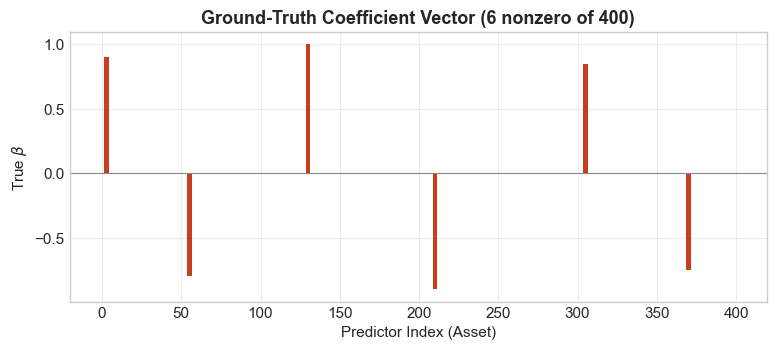

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.axhline(0, color='#888888', linewidth=0.8)
ax.bar(range(N), beta_true, color='#888888', width=1.0)
for idx in leader_idx:
    ax.bar(idx, beta_true[idx], color='#C73E1D', width=3)
ax.set_xlabel('Predictor Index (Asset)'); ax.set_ylabel(r'True $\beta$')
ax.set_title('Ground-Truth Coefficient Vector (6 nonzero of 400)')
plt.show()

## 4. Train / Test Split

The first **7.75 years (1,765 days)** are used for fitting; the **final 250 trading days** — completely unseen by any model — are reserved for out-of-sample evaluation.

In [6]:
from sklearn.preprocessing import StandardScaler

n_total = len(y_all)
n_test = 250
n_train = n_total - n_test

X_train, X_test = X_all[:n_train], X_all[n_train:]
y_train, y_test = y_all[:n_train], y_all[n_train:]

scaler = StandardScaler().fit(X_train)          # fit on train only
X_train_std = scaler.transform(X_train)
X_test_std = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} days   |   Test (out-of-sample): {X_test.shape[0]} days")

Train: 1765 days   |   Test (out-of-sample): 250 days


## 5. Fitting the Four Models

### 5.1 Principal Component Regression (PCR)

The number of components $k$ is chosen by 5-fold cross-validation on the training set — the same PCA machinery from the previous notebook, but now with $k$ picked to maximize *predictive* performance rather than a fixed variance threshold.

In [7]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.model_selection import cross_val_score

k_grid = range(1, 41, 2)
cv_scores = []
for k in k_grid:
    Z = PCA(n_components=k, random_state=0).fit_transform(X_train_std)
    cv_scores.append(cross_val_score(LinearRegression(), Z, y_train, cv=5, scoring='r2').mean())

best_k = list(k_grid)[int(np.argmax(cv_scores))]
print(f"PCR: selected k = {best_k} components (of {N}) by cross-validated R^2")

pca_model = PCA(n_components=best_k, random_state=0).fit(X_train_std)
Z_train, Z_test = pca_model.transform(X_train_std), pca_model.transform(X_test_std)
pcr_model = LinearRegression().fit(Z_train, y_train)

pred_pcr_train = pcr_model.predict(Z_train)
pred_pcr_test = pcr_model.predict(Z_test)

PCR: selected k = 23 components (of 400) by cross-validated R^2


### 5.2 OLS

Plain least squares on all 400 lagged returns, no regularization.

In [8]:
ols_model = LinearRegression().fit(X_train, y_train)
pred_ols_train = ols_model.predict(X_train)
pred_ols_test = ols_model.predict(X_test)

print(f"OLS train R^2: {ols_model.score(X_train, y_train):.3f}")
print(f"OLS test  R^2: {ols_model.score(X_test, y_test):.3f}")

OLS train R^2: 0.324
OLS test  R^2: -0.171


### 5.3 Lasso

Regularization strength $\lambda$ is chosen by 5-fold cross-validation (`LassoCV`) on the standardized training predictors.

In [9]:
lasso_model = LassoCV(cv=5, random_state=0, max_iter=20000).fit(X_train_std, y_train)
pred_lasso_train = lasso_model.predict(X_train_std)
pred_lasso_test = lasso_model.predict(X_test_std)

lasso_selected = np.where(lasso_model.coef_ != 0)[0]
true_positives = sorted(set(lasso_selected) & set(leader_idx))

print(f"Lasso: alpha = {lasso_model.alpha_:.5f}")
print(f"Nonzero coefficients: {len(lasso_selected)} of {N}")
print(f"True leaders recovered: {len(true_positives)} of {len(leader_idx)}  -> {true_positives}")

Lasso: alpha = 0.00308
Nonzero coefficients: 29 of 400
True leaders recovered: 6 of 6  -> [3, 55, 130, 210, 305, 370]


### 5.4 Post-Lasso / Double Selection ("Double Learning")

The training set is split into two independent halves. Lasso is run separately on each half, and only predictors selected by **both** halves are kept — a cross-fitting scheme that filters out selections driven by chance correlation in any one sample. An ordinary, unpenalized OLS is then refit on the full training set restricted to that intersection, removing Lasso's shrinkage bias for the surviving coefficients.

In [10]:
half = n_train // 2
lasso_a = LassoCV(cv=5, random_state=0, max_iter=20000).fit(X_train_std[:half], y_train[:half])
lasso_b = LassoCV(cv=5, random_state=0, max_iter=20000).fit(X_train_std[half:], y_train[half:])

support_a = np.where(lasso_a.coef_ != 0)[0]
support_b = np.where(lasso_b.coef_ != 0)[0]
double_support = np.intersect1d(support_a, support_b)
if len(double_support) == 0:                     # fallback safety net
    double_support = lasso_selected

postlasso_model = LinearRegression().fit(X_train_std[:, double_support], y_train)
pred_pl_train = postlasso_model.predict(X_train_std[:, double_support])
pred_pl_test = postlasso_model.predict(X_test_std[:, double_support])

true_positives_pl = sorted(set(double_support) & set(leader_idx))
print(f"Double-selection support: {len(double_support)} predictors (of {N})")
print(f"True leaders recovered: {len(true_positives_pl)} of {len(leader_idx)}  -> {true_positives_pl}")

Double-selection support: 8 predictors (of 400)
True leaders recovered: 6 of 6  -> [3, 55, 130, 210, 305, 370]


## 6. Coefficient Recovery (Diagram)

Converting each model's coefficients back to raw-return units and comparing them to the six true leader coefficients shows the bias/variance story directly: OLS estimates are noisy (sometimes overshooting), Lasso estimates are all visibly shrunk toward zero, and post-Lasso estimates land closest to the true values.

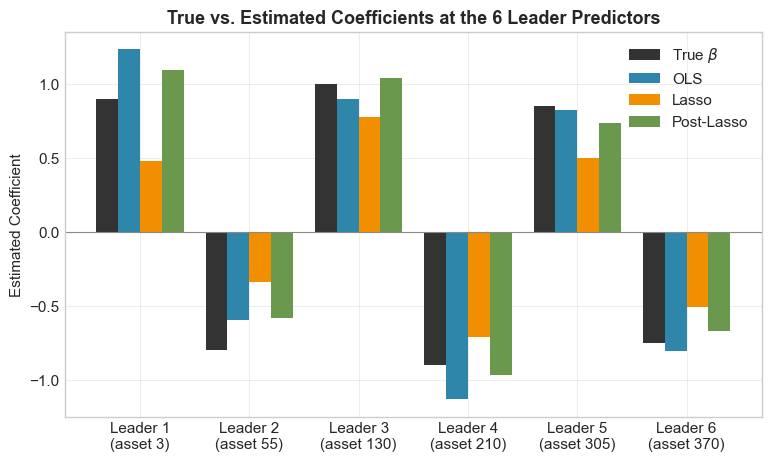

In [11]:
coef_ols_raw = ols_model.coef_
coef_lasso_raw = lasso_model.coef_ / scaler.scale_
coef_pl_raw = np.zeros(N)
coef_pl_raw[double_support] = postlasso_model.coef_ / scaler.scale_[double_support]

fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(leader_idx))
width = 0.2
ax.bar(x_pos - 1.5*width, beta_vals, width, color='#333333', label='True $\\beta$')
ax.bar(x_pos - 0.5*width, coef_ols_raw[leader_idx], width, color='#2E86AB', label='OLS')
ax.bar(x_pos + 0.5*width, coef_lasso_raw[leader_idx], width, color='#F18F01', label='Lasso')
ax.bar(x_pos + 1.5*width, coef_pl_raw[leader_idx], width, color='#6A994E', label='Post-Lasso')
ax.set_xticks(x_pos); ax.set_xticklabels([f'Leader {i+1}\n(asset {idx})' for i, idx in enumerate(leader_idx)])
ax.axhline(0, color='#888888', linewidth=0.8)
ax.set_ylabel('Estimated Coefficient')
ax.set_title('True vs. Estimated Coefficients at the 6 Leader Predictors')
ax.legend()
plt.show()

## 7. Out-of-Sample Cumulative Return Tracking

Every model was fit once, on the training period only. Each one now generates a forecast for each of the 250 held-out test days using that day's (already-realized, lagged) predictors. Summing the forecasts and comparing to the summed actual returns shows how closely each model's cumulative return *trace* follows reality — the central question this notebook set out to answer.

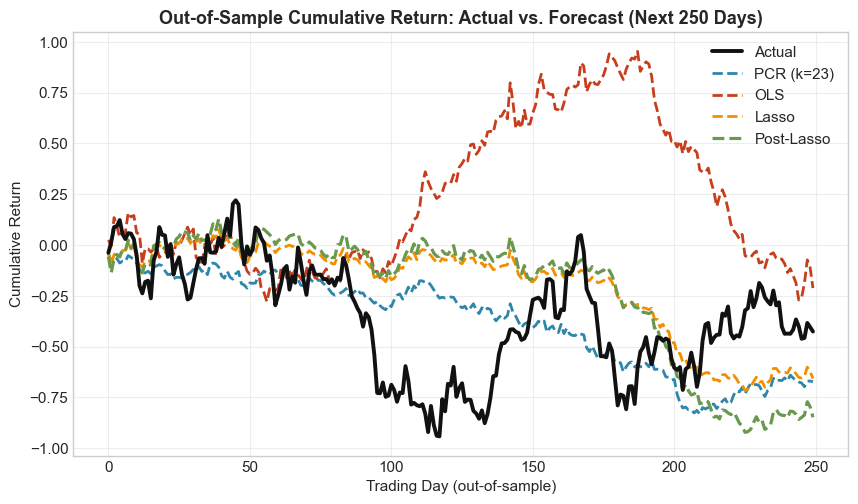

In [12]:
actual_cum = np.cumsum(y_test)
pcr_cum = np.cumsum(pred_pcr_test)
ols_cum = np.cumsum(pred_ols_test)
lasso_cum = np.cumsum(pred_lasso_test)
pl_cum = np.cumsum(pred_pl_test)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(actual_cum, color='#111111', linewidth=2.8, label='Actual', zorder=5)
ax.plot(pcr_cum, color='#2E86AB', linewidth=2, linestyle='--', label=f'PCR (k={best_k})')
ax.plot(ols_cum, color='#C73E1D', linewidth=2, linestyle='--', label='OLS')
ax.plot(lasso_cum, color='#F18F01', linewidth=2, linestyle='--', label='Lasso')
ax.plot(pl_cum, color='#6A994E', linewidth=2.3, linestyle='--', label='Post-Lasso')
ax.set_xlabel('Trading Day (out-of-sample)'); ax.set_ylabel('Cumulative Return')
ax.set_title('Out-of-Sample Cumulative Return: Actual vs. Forecast (Next 250 Days)')
ax.legend()
plt.show()

## 8. Error Analysis

**Left:** per-model RMSE and out-of-sample $R^2$ on daily returns. **Right:** the tracking error — the running absolute gap between each model's cumulative forecast and the actual cumulative return — showing how errors accumulate (or don't) over the 250-day horizon.

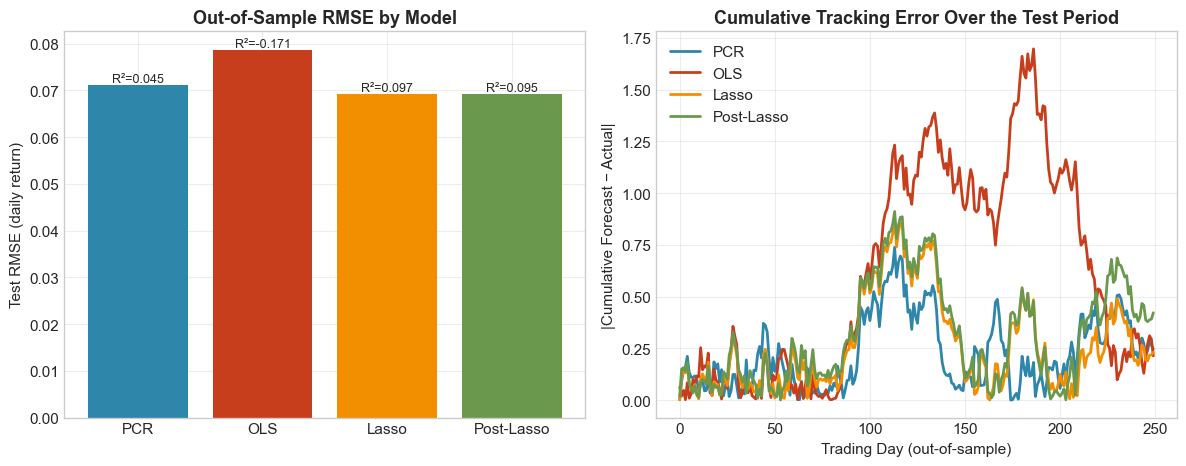

In [13]:
models = {
    'PCR': (pred_pcr_test, pcr_cum),
    'OLS': (pred_ols_test, ols_cum),
    'Lasso': (pred_lasso_test, lasso_cum),
    'Post-Lasso': (pred_pl_test, pl_cum),
}
colors = {'PCR': '#2E86AB', 'OLS': '#C73E1D', 'Lasso': '#F18F01', 'Post-Lasso': '#6A994E'}

rmse = {m: np.sqrt(np.mean((y_test - pred) ** 2)) for m, (pred, _) in models.items()}
r2 = {m: 1 - np.sum((y_test - pred) ** 2) / np.sum((y_test - y_test.mean()) ** 2) for m, (pred, _) in models.items()}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

ax = axes[0]
bars = ax.bar(models.keys(), [rmse[m] for m in models], color=[colors[m] for m in models])
ax.set_ylabel('Test RMSE (daily return)')
ax.set_title('Out-of-Sample RMSE by Model')
for b, m in zip(bars, models):
    ax.annotate(f"R²={r2[m]:.3f}", (b.get_x() + b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=9)

ax = axes[1]
for m, (_, cum) in models.items():
    tracking_error = np.abs(cum - actual_cum)
    ax.plot(tracking_error, color=colors[m], linewidth=2, label=m)
ax.set_xlabel('Trading Day (out-of-sample)'); ax.set_ylabel('|Cumulative Forecast − Actual|')
ax.set_title('Cumulative Tracking Error Over the Test Period')
ax.legend()

plt.tight_layout()
plt.show()

## 9. Summary

In [14]:
final_gap = {m: abs(cum[-1] - actual_cum[-1]) for m, (_, cum) in models.items()}
n_selected = {'PCR': best_k, 'OLS': N, 'Lasso': len(lasso_selected), 'Post-Lasso': len(double_support)}

print(f"{'Model':<12}{'Test RMSE':>12}{'Test R2':>10}{'Predictors':>12}{'Final Cum. Gap':>18}")
for m in models:
    print(f"{m:<12}{rmse[m]:>12.4f}{r2[m]:>10.3f}{n_selected[m]:>12}{final_gap[m]:>18.4f}")

Model          Test RMSE   Test R2  Predictors    Final Cum. Gap
PCR               0.0711     0.045          23            0.2473
OLS               0.0787    -0.171         400            0.2138
Lasso             0.0691     0.097          29            0.2312
Post-Lasso        0.0692     0.095           8            0.4222


- **OLS** fits the training noise as readily as the true signal (highest train $R^2$, but negative test $R^2$). With 400 correlated predictors and no penalty, it swings to a confidently *wrong-directional* forecast mid-period — its tracking error peaks at roughly triple the other three models' — because it has no way to distinguish the 6 true leaders from the other 394.
- **PCR, Lasso, and Post-Lasso** all avoid that failure: their tracking error stays in a much tighter band throughout the 250 days, showing that both dimensionality reduction and sparse selection successfully control overfitting where OLS does not.
- **PCR**'s components are built to capture variance, not necessarily predictive signal — since the true signal here is concentrated in 6 individual assets rather than a broad co-movement pattern, PCR's tracking is respectable but not the tightest of the three.
- **Lasso vs. Post-Lasso** land at essentially the same predictive RMSE ($0.069$ vs. $0.069$) and out-of-sample $R^2$ ($0.097$ vs. $0.095$) — post-Lasso's benefit isn't extra predictive accuracy here. Its clear advantage shows up in Section 6: it recovers coefficients close to the true $\beta$ at every one of the 6 leaders, while Lasso's estimates are *systematically* shrunk toward zero. Predictive accuracy and unbiasedness are different goals, and double selection targets the second one directly.